# SETUP

In [1]:
# Janky code to do different setup when run in a Colab notebook vs VSCode
import os

from IPython import get_ipython

ipython = get_ipython()
# Code to automatically update the HookedTransformer code as its edited without restarting the kernel
ipython.magic("load_ext autoreload")
ipython.magic("autoreload 2")

# Import stuff
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import einops
from fancy_einsum import einsum
import tqdm.notebook as tqdm
import random
from pathlib import Path
import plotly.express as px
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

from torchtyping import TensorType as TT
from typing import List, Union, Optional, Callable
from functools import partial
import copy
import itertools
import json

from transformers import AutoModelForCausalLM, AutoConfig, AutoTokenizer
import dataclasses
import datasets
from IPython.display import HTML, Markdown
import umap

C:\Users\Danik\AppData\Local\Temp\ipykernel_7868\2315760820.py:8: DeprecationWarning: `magic(...)` is deprecated since IPython 0.13 (warning added in 8.1), use run_line_magic(magic_name, parameter_s).
  ipython.magic("load_ext autoreload")
C:\Users\Danik\AppData\Local\Temp\ipykernel_7868\2315760820.py:9: DeprecationWarning: `magic(...)` is deprecated since IPython 0.13 (warning added in 8.1), use run_line_magic(magic_name, parameter_s).
  ipython.magic("autoreload 2")
c:\Users\Danik\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


In [2]:
import transformer_lens
import transformer_lens.utils as utils
from transformer_lens.hook_points import (
    HookedRootModule,
    HookPoint,
)  # Hooking utilities
from transformer_lens import (
    HookedTransformer,
    HookedTransformerConfig,
    FactoredMatrix,
    ActivationCache,
)

In [3]:
from neel_plotly import line, imshow, scatter
import plotly.io as pio
pio.renderers.default = 'vscode'

import transformer_lens.patching as patching

from typing_extensions import Literal

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA

## IOI SETUP

In [4]:
model = HookedTransformer.from_pretrained("gpt2-small")


model.set_use_attn_result(True)
model.set_use_attn_in(True)
model.set_use_hook_mlp_in(True)

Loaded pretrained model gpt2-small into HookedTransformer


In [5]:
prompts = [
    "When John and Mary went to the shops, John gave the bag to",
    "When John and Mary went to the shops, Mary gave the bag to",
    "When Tom and James went to the park, James gave the ball to",
    "When Tom and James went to the park, Tom gave the ball to",
    "When Dan and Sid went to the shops, Sid gave an apple to",
    "When Dan and Sid went to the shops, Dan gave an apple to",
    "After Martin and Amy went to the park, Amy gave a drink to",
    "After Martin and Amy went to the park, Martin gave a drink to",
]
answers = [
    (" Mary", " John"),
    (" John", " Mary"),
    (" Tom", " James"),
    (" James", " Tom"),
    (" Dan", " Sid"),
    (" Sid", " Dan"),
    (" Martin", " Amy"),
    (" Amy", " Martin"),
]

clean_tokens = model.to_tokens(prompts)
# Swap each adjacent pair, with a hacky list comprehension
corrupted_tokens = clean_tokens[
    [(i + 1 if i % 2 == 0 else i - 1) for i in range(len(clean_tokens))]
]
print("Clean string 0", model.to_string(clean_tokens[0]))
print("Corrupted string 0", model.to_string(corrupted_tokens[0]))

answer_token_indices = torch.tensor(
    [
        [model.to_single_token(answers[i][j]) for j in range(2)]
        for i in range(len(answers))
    ],
    device=model.cfg.device,
)
print("Answer token indices", answer_token_indices)

Clean string 0 <|endoftext|>When John and Mary went to the shops, John gave the bag to
Corrupted string 0 <|endoftext|>When John and Mary went to the shops, Mary gave the bag to
Answer token indices tensor([[ 5335,  1757],
        [ 1757,  5335],
        [ 4186,  3700],
        [ 3700,  4186],
        [ 6035, 15686],
        [15686,  6035],
        [ 5780, 14235],
        [14235,  5780]])


In [6]:
def get_logit_diff(logits, answer_token_indices=answer_token_indices):
    if len(logits.shape) == 3:
        # Get final logits only
        logits = logits[:, -1, :]
    correct_logits = logits.gather(1, answer_token_indices[:, 0].unsqueeze(1))
    incorrect_logits = logits.gather(1, answer_token_indices[:, 1].unsqueeze(1))
    return (correct_logits - incorrect_logits).mean()


clean_logits, clean_cache = model.run_with_cache(clean_tokens)
corrupted_logits, corrupted_cache = model.run_with_cache(corrupted_tokens)

clean_logit_diff = get_logit_diff(clean_logits, answer_token_indices).item()
print(f"Clean logit diff: {clean_logit_diff:.4f}")

corrupted_logit_diff = get_logit_diff(corrupted_logits, answer_token_indices).item()
print(f"Corrupted logit diff: {corrupted_logit_diff:.4f}")

Clean logit diff: 3.5519
Corrupted logit diff: -3.5519


In [7]:
CLEAN_BASELINE = clean_logit_diff
CORRUPTED_BASELINE = corrupted_logit_diff


def ioi_metric(logits, answer_token_indices=answer_token_indices):
    return (get_logit_diff(logits, answer_token_indices) - CORRUPTED_BASELINE) / (
        CLEAN_BASELINE - CORRUPTED_BASELINE
    )

In [8]:
def filter_mlp_hooks(name):
    return "mlp" in name

def get_cache_fwd_and_bwd(model, tokens, metric):
    model.reset_hooks()
    cache = {}

    def forward_cache_hook(act, hook):
        cache[hook.name] = act.detach()

    model.add_hook(filter_mlp_hooks, forward_cache_hook, "fwd")

    grad_cache = {}

    def backward_cache_hook(act, hook):
        grad_cache[hook.name] = act.detach()

    model.add_hook(filter_mlp_hooks, backward_cache_hook, "bwd")

    value = metric(model(tokens))
    value.backward()
    model.reset_hooks()
    return (
        value.item(),
        ActivationCache(cache, model),
        ActivationCache(grad_cache, model),
    )

clean_value, clean_cache, clean_grad_cache = get_cache_fwd_and_bwd(
    model, clean_tokens, ioi_metric
)

corrupted_value, corrupted_cache, corrupted_grad_cache = get_cache_fwd_and_bwd(
    model, corrupted_tokens, ioi_metric
)


In [9]:
def stack_mlp_from_cache(cache, activation_name: Literal["mlp_in", "mlp_out", "pre", "post"]):
    stacked_mlp_vectors = torch.stack(
        [cache[activation_name, l] for l in range(model.cfg.n_layers)], dim=0
    )

    return stacked_mlp_vectors

# Clustering Neurons 

## Computing Attribution Vectors

In [10]:
num_layers = model.cfg.n_layers

def stack_w_out():
    W_out_stacked = torch.stack(
        [model.blocks[l].mlp.W_out for l in range(num_layers)], dim=0
    )

    return W_out_stacked


def get_mlp_output_attribution_matrices(clean_cache, sum_over_pos=False, weighted_by_attribution_score=False):
    clean_act_post = stack_mlp_from_cache(clean_cache, "post")

    clean_act_post = einops.reduce(
        clean_act_post,
        "layer batch pos dim -> layer pos dim",
        "sum"
    )

    W_out_stacked = stack_w_out()

    W_out_stacked = einops.rearrange(
        W_out_stacked,
        "layer d_mlp d_embed -> layer d_embed d_mlp"
    )

    attribution_matrices = einops.einsum(
        clean_act_post,
        W_out_stacked,
        "layer pos d_mlp, layer d_embed d_mlp -> layer pos d_embed d_mlp"
    )


    attribution_matrices = einops.rearrange(
        attribution_matrices,
        "layer pos d_embed d_mlp -> layer pos d_mlp d_embed"
    )

    if(weighted_by_attribution_score):
        clean_act = stack_mlp_from_cache(clean_cache, "post")
        corrupted_act = stack_mlp_from_cache(corrupted_cache, "post")
        grad_vector = stack_mlp_from_cache(corrupted_grad_cache, "post")
        
        attribution_scores = einops.reduce(
            grad_vector * (clean_act - corrupted_act),
            "layer batch pos dim -> layer pos dim",
            "sum"
        )

        attribution_matrices = einops.einsum(
            attribution_scores,
            attribution_matrices,
            "layer pos d_mlp, layer pos d_mlp d_embed -> layer pos d_mlp d_embed"
        )

    if(sum_over_pos):
        return einops.reduce(
            attribution_matrices,
            "layer pos d_mlp d_embed -> layer d_mlp d_embed",
            "sum"
        )
    
    else:
        return einops.rearrange(
            attribution_matrices,
            "layer pos d_mlp d_embed -> layer (pos d_mlp) d_embed"
        )


def throw_low_activation_neuron(clean_cache, attributions, threshold=0.1):
    clean_act = stack_mlp_from_cache(clean_cache, "post")
    
    clean_act = einops.reduce(
        torch.abs(clean_act),
        "layer batch pos d_mlp -> layer pos d_mlp",
        "sum"
    )
    
    clean_act = einops.rearrange(
        clean_act,
        "layer pos d_mlp -> layer (pos d_mlp)",
    )
    mask = clean_act > threshold

    while(mask.dim() < attributions.dim()):
        mask = mask.unsqueeze(-1)
    
    
    mask = mask.expand_as(attributions)
    
    filtered_out = attributions * mask
    
    return filtered_out  

## Unweighted Clustering

In [11]:
attr = get_mlp_output_attribution_matrices(clean_cache)
attr = throw_low_activation_neuron(clean_cache, attr, threshold=0.2)

### Cluster

In [12]:
max_centroids = 10

layer_inertias = []
layer_filtered_inertias = []

for l in range(3):
    non_empty_mask = attr[l].abs().sum(dim=1).bool()
    filtered_data = attr[l, non_empty_mask, :].cpu().detach().numpy()
    data = attr[l].cpu().detach().numpy()
    inertias = []
    filtered_inertias = []

    for i in range(1,max_centroids+1):
        kmeans = KMeans(n_clusters=i)
        kmeans.fit(data)
        inertias.append(kmeans.inertia_)
        kmeans.fit(filtered_data)
        filtered_inertias.append(kmeans.inertia_)
        
    layer_inertias.append(inertias)
    layer_filtered_inertias.append(filtered_inertias)

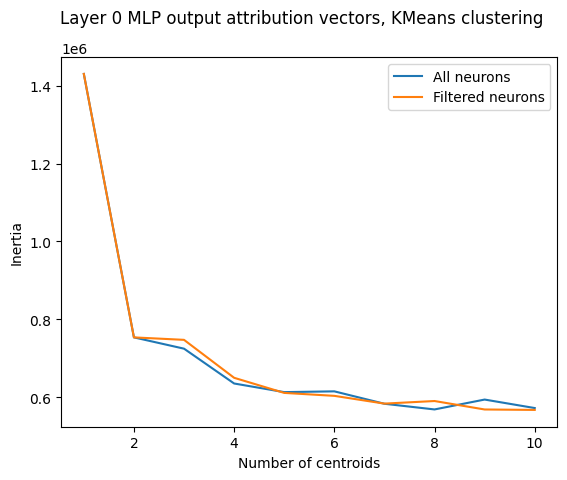

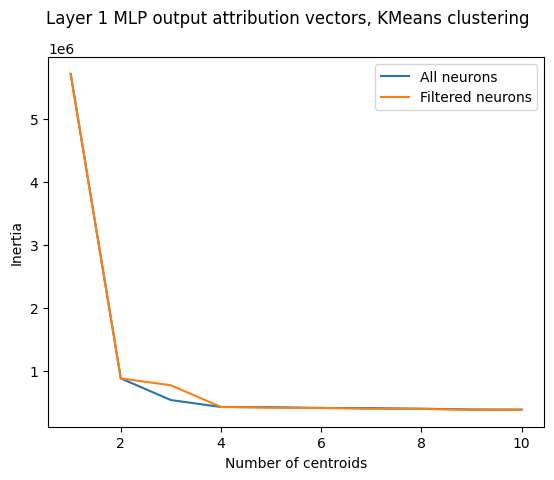

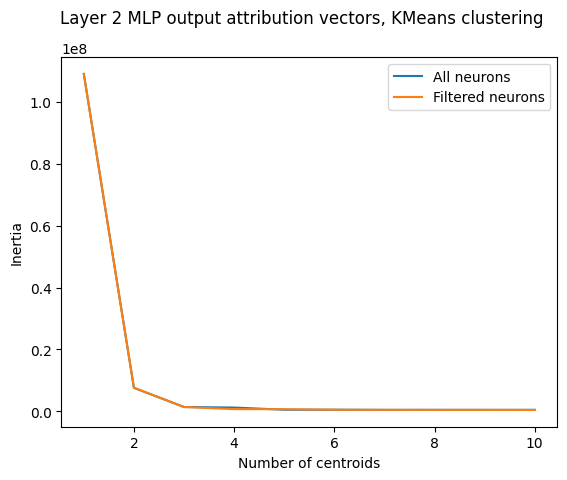

In [13]:
for l in range(3):
    fig, ax = plt.subplots()
    fig.suptitle(f"Layer {l} MLP output attribution vectors, KMeans clustering")
    ax.set_xlabel("Number of centroids")
    ax.set_ylabel("Inertia")
    ax.plot(range(1,max_centroids+1), layer_inertias[l], label="All neurons")
    ax.plot(range(1,max_centroids+1), layer_filtered_inertias[l], label="Filtered neurons")
    plt.legend()

### Plot

In [14]:
embeddings = []
for l in range(num_layers):
    reducer = umap.UMAP()
    non_empty_mask = attr[l].abs().sum(dim=1).bool()
    embeddings.append(reducer.fit_transform(attr[l,non_empty_mask,:].cpu().detach().numpy()))

c:\Users\Danik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:329: UserWarning:

Graph is not fully connected, spectral embedding may not work as expected.



C:\Users\Danik\AppData\Local\Temp\ipykernel_7868\1578353218.py:9: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



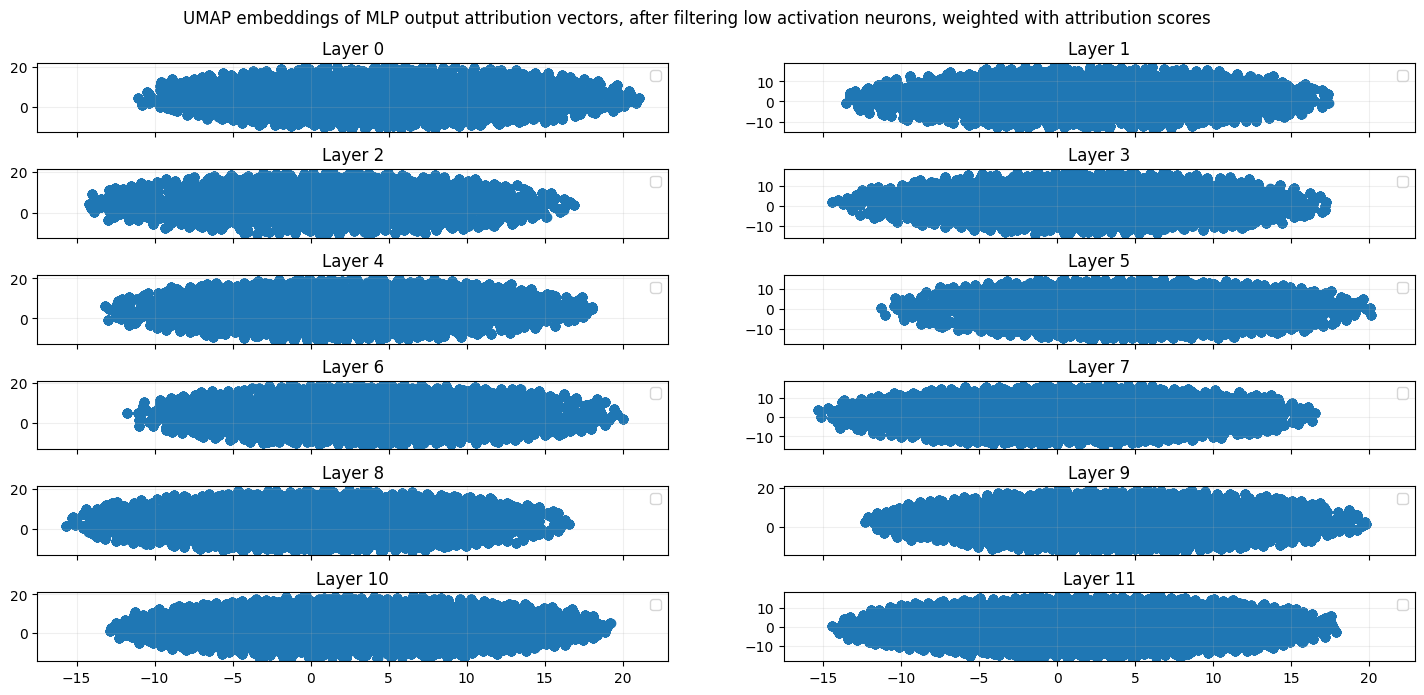

In [15]:
fig, axes = plt.subplots(6, 2, sharex=True, figsize=(7, 8))

l=0
for ax in axes:
    for subplot in ax:
        subplot.scatter(embeddings[l][:,0], embeddings[l][:,1])
        subplot.set_title(f"Layer {l}")
        subplot.grid(alpha=0.2)
        subplot.legend()

        l+=1

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space at top for suptitle
plt.suptitle('UMAP embeddings of MLP output attribution vectors, after filtering low activation neurons, weighted with attribution scores')
plt.gcf().set_size_inches(15, 7)  # Make the figure wider

## Weighted Clustering

In [16]:
attr = get_mlp_output_attribution_matrices(clean_cache, weighted_by_attribution_score=True)
attr = throw_low_activation_neuron(clean_cache, attr, threshold=0.2)

### Cluster

In [17]:
max_centroids = 10

layer_inertias = []
layer_filtered_inertias = []

for l in range(num_layers):
    non_empty_mask = attr[l].abs().sum(dim=1).bool()
    filtered_data = attr[l, non_empty_mask, :].cpu().detach().numpy()
    data = attr[l].cpu().detach().numpy()
    inertias = []
    filtered_inertias = []

    for i in range(1,max_centroids+1):
        kmeans = KMeans(n_clusters=i)
        kmeans.fit(data)
        inertias.append(kmeans.inertia_)
        kmeans.fit(filtered_data)
        filtered_inertias.append(kmeans.inertia_)
        
    layer_inertias.append(inertias)
    layer_filtered_inertias.append(filtered_inertias)

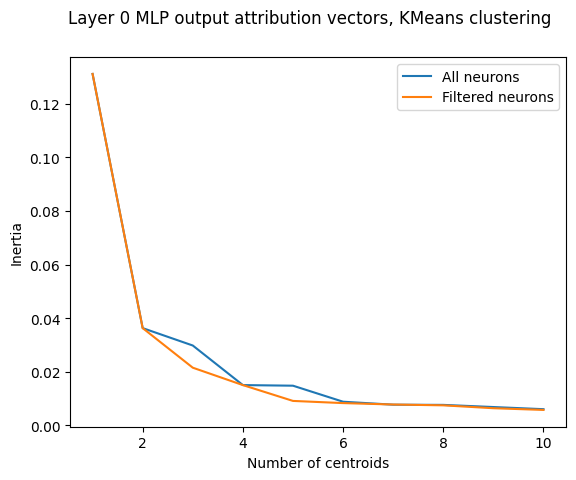

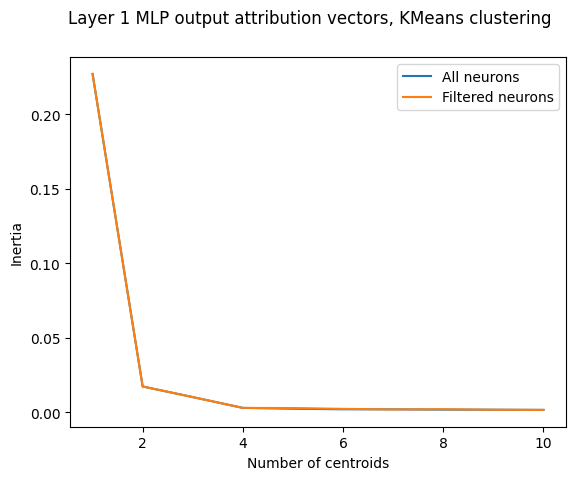

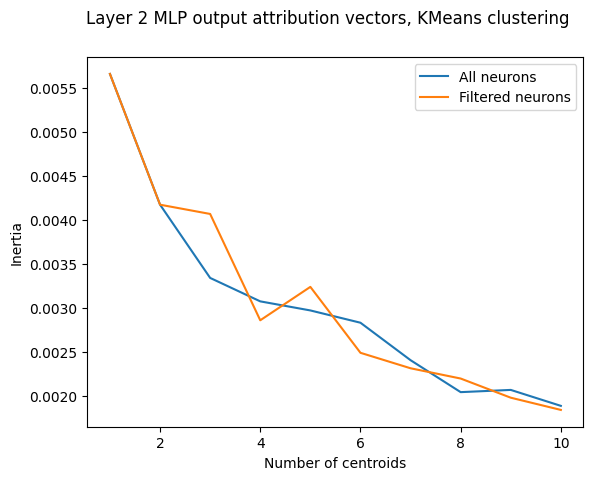

In [18]:
for l in range(3):
    fig, ax = plt.subplots()
    fig.suptitle(f"Layer {l} MLP output attribution vectors, KMeans clustering")
    ax.set_xlabel("Number of centroids")
    ax.set_ylabel("Inertia")
    ax.plot(range(1,max_centroids+1), layer_inertias[l], label="All neurons")
    ax.plot(range(1,max_centroids+1), layer_filtered_inertias[l], label="Filtered neurons")
    plt.legend()

### Plot

In [19]:
embeddings = []
for l in range(num_layers):
    reducer = umap.UMAP()
    non_empty_mask = attr[l].abs().sum(dim=1).bool()
    embeddings.append(reducer.fit_transform(attr[l,non_empty_mask,:].cpu().detach().numpy()))

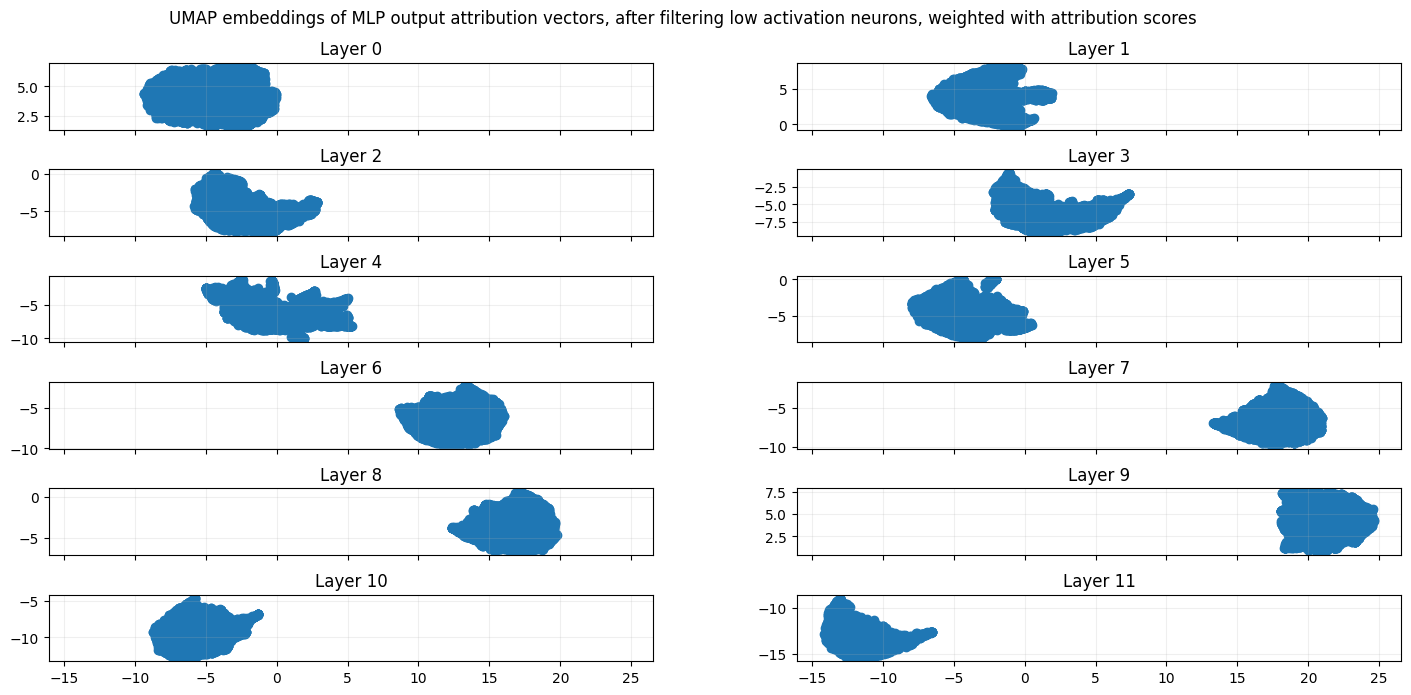

In [20]:
fig, axes = plt.subplots(6, 2, sharex=True, figsize=(7, 8))

l=0
for ax in axes:
    for subplot in ax:
        subplot.scatter(embeddings[l][:,0], embeddings[l][:,1])
        subplot.set_title(f"Layer {l}")
        subplot.grid(alpha=0.2)

        l+=1

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space at top for suptitle
plt.suptitle('UMAP embeddings of MLP output attribution vectors, after filtering low activation neurons, weighted with attribution scores')
plt.gcf().set_size_inches(15, 7)  # Make the figure wider

In [21]:
pca_data = []
for l in range(num_layers):
    non_empty_mask = attr[l].abs().sum(dim=1).bool()
    data = attr[l,non_empty_mask,:].cpu().detach().numpy()

    pca = PCA(n_components=min(data.shape[0], data.shape[1], 128))
    pca_result = pca.fit_transform(data)
    pca_data.append(pca_result)


embeddings = []
for l in range(num_layers):
    reducer = umap.UMAP()
    embeddings.append(reducer.fit_transform(pca_data[l]))


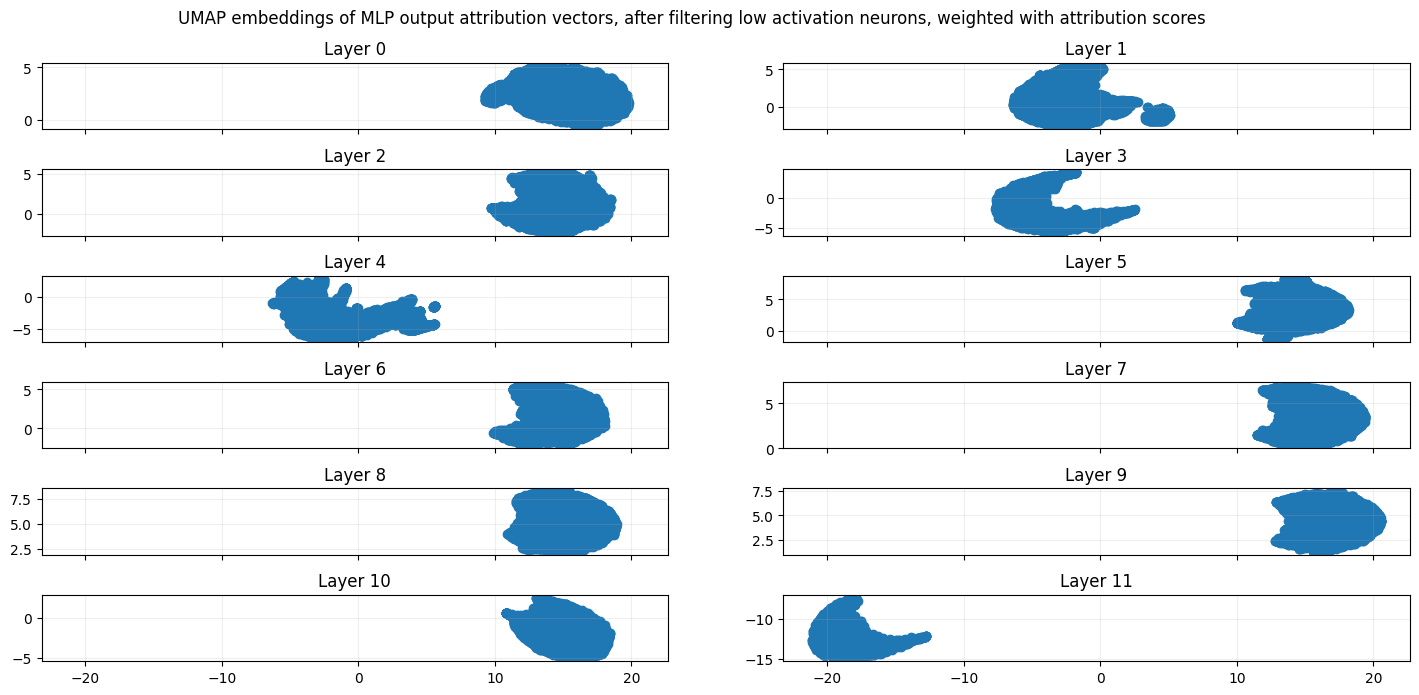

In [22]:
fig, axes = plt.subplots(6, 2, sharex=True, figsize=(7, 8))

l=0
for ax in axes:
    for subplot in ax:
        subplot.scatter(embeddings[l][:,0], embeddings[l][:,1])
        subplot.set_title(f"Layer {l}")
        subplot.grid(alpha=0.2)

        l+=1

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space at top for suptitle
plt.suptitle('UMAP embeddings of MLP output attribution vectors, after filtering low activation neurons, weighted with attribution scores')
plt.gcf().set_size_inches(15, 7)  # Make the figure wider

### Filtered

In [23]:
max_centroids = 10
min_centroids = 1
centroids = {}

best_ks = []

k=1
for l in range(num_layers):    
    non_empty_mask = attr[l].abs().sum(dim=1).bool()
    data = attr[l, non_empty_mask, :].cpu().detach().numpy()
    inertias = []
    current_centroids = []
    sil_score = []

    for i in range(min_centroids, max_centroids):
        kmeans = KMeans(n_clusters=i)
        cluster_labels = kmeans.fit_predict(data)
        current_centroids.append(kmeans.cluster_centers_)
        if(i != 1):
            sil_score.append(silhouette_score(data, cluster_labels))
        inertias.append(kmeans.inertia_)
        
    k = sil_score.index(max(sil_score)) + max(min_centroids, 2)
    best_ks.append(k)
    
    centroids[l] = current_centroids[k - max(min_centroids, 2) + 1]

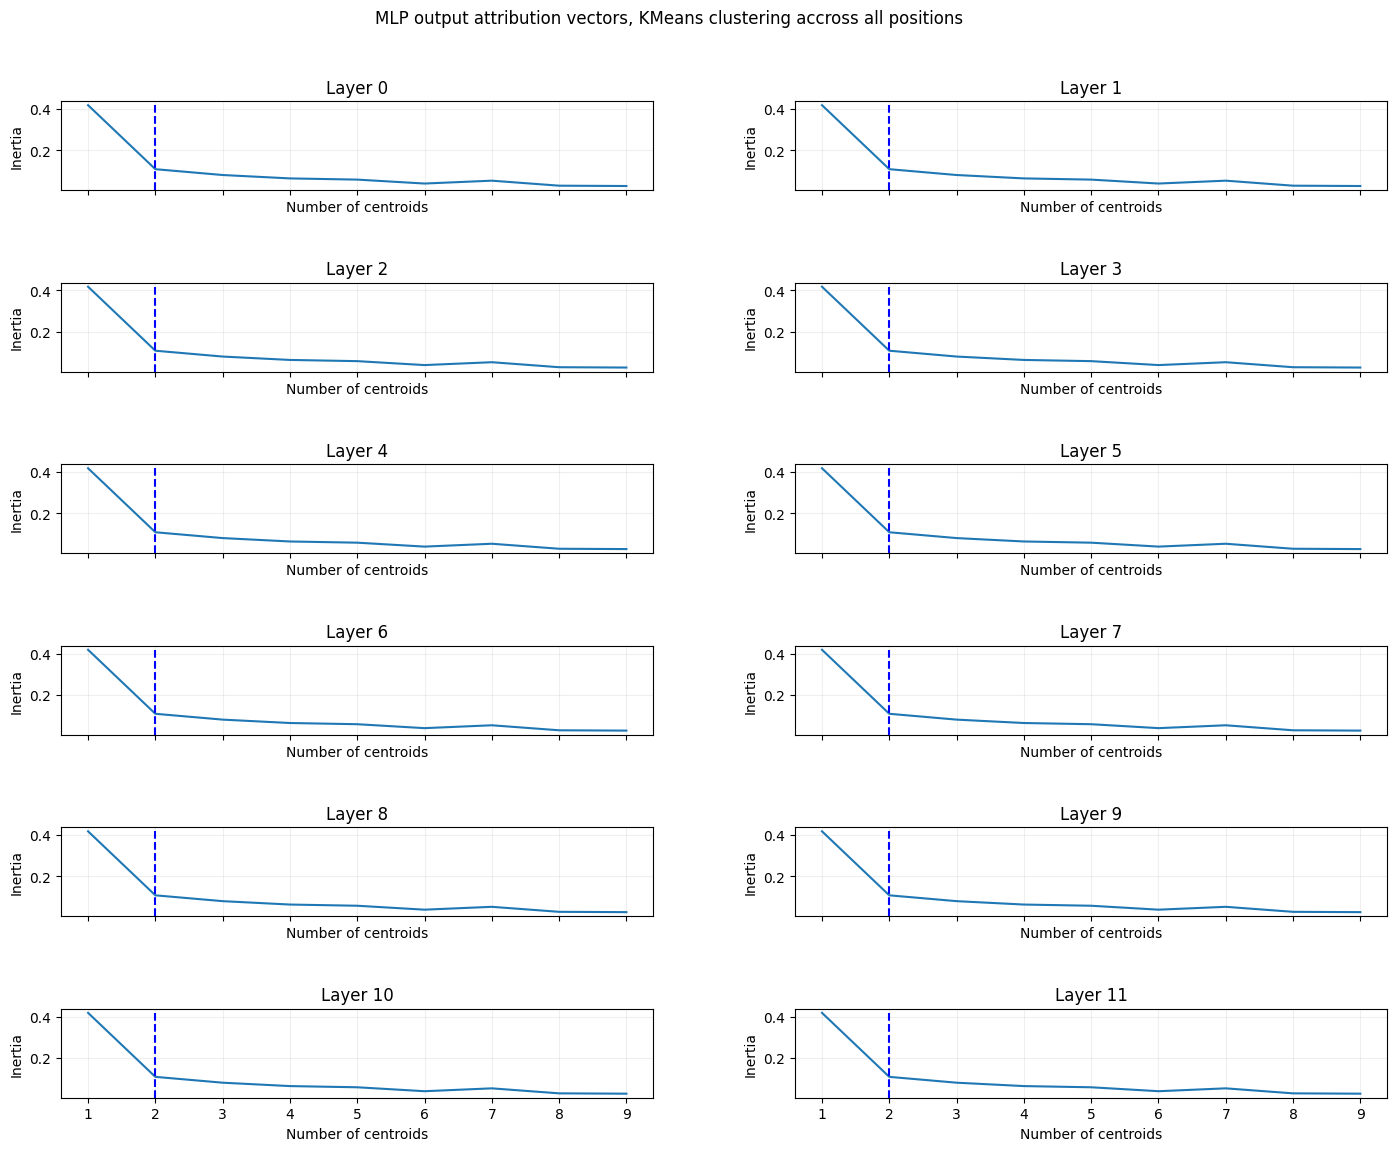

In [24]:
fig, axes = plt.subplots(6, 2, sharex=True, figsize=(7, 8))

l=0
for ax in axes:

    for subplot in ax:
        subplot.set_xlabel("Number of centroids")
        subplot.set_ylabel("Inertia")
        
        subplot.plot(range(min_centroids,max_centroids), inertias)
        subplot.axvline(x = best_ks[l], color = 'b', linestyle = '--')

        subplot.set_title(f"Layer {l}")
        subplot.grid(alpha=0.2)

        l+=1

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space at top for suptitle
plt.suptitle(f"MLP output attribution vectors, KMeans clustering accross all positions")
plt.gcf().set_size_inches(15, 12)  # Make the figure wider

### Plot

In [25]:
pca_data = []
for l in range(num_layers):
    non_empty_mask = attr[l].abs().sum(dim=1).bool()
    data = attr[l,non_empty_mask,:].cpu().detach().numpy()
    combined_data = np.concatenate([data, centroids[l]], axis=0)

    pca = PCA(n_components=min(combined_data.shape[0], combined_data.shape[1], 128))
    pca_result = pca.fit_transform(combined_data)
    pca_data.append(pca_result)


In [26]:
embeddings = []
for l in range(num_layers):
    reducer = umap.UMAP()
    embeddings.append(reducer.fit_transform(pca_data[l]))

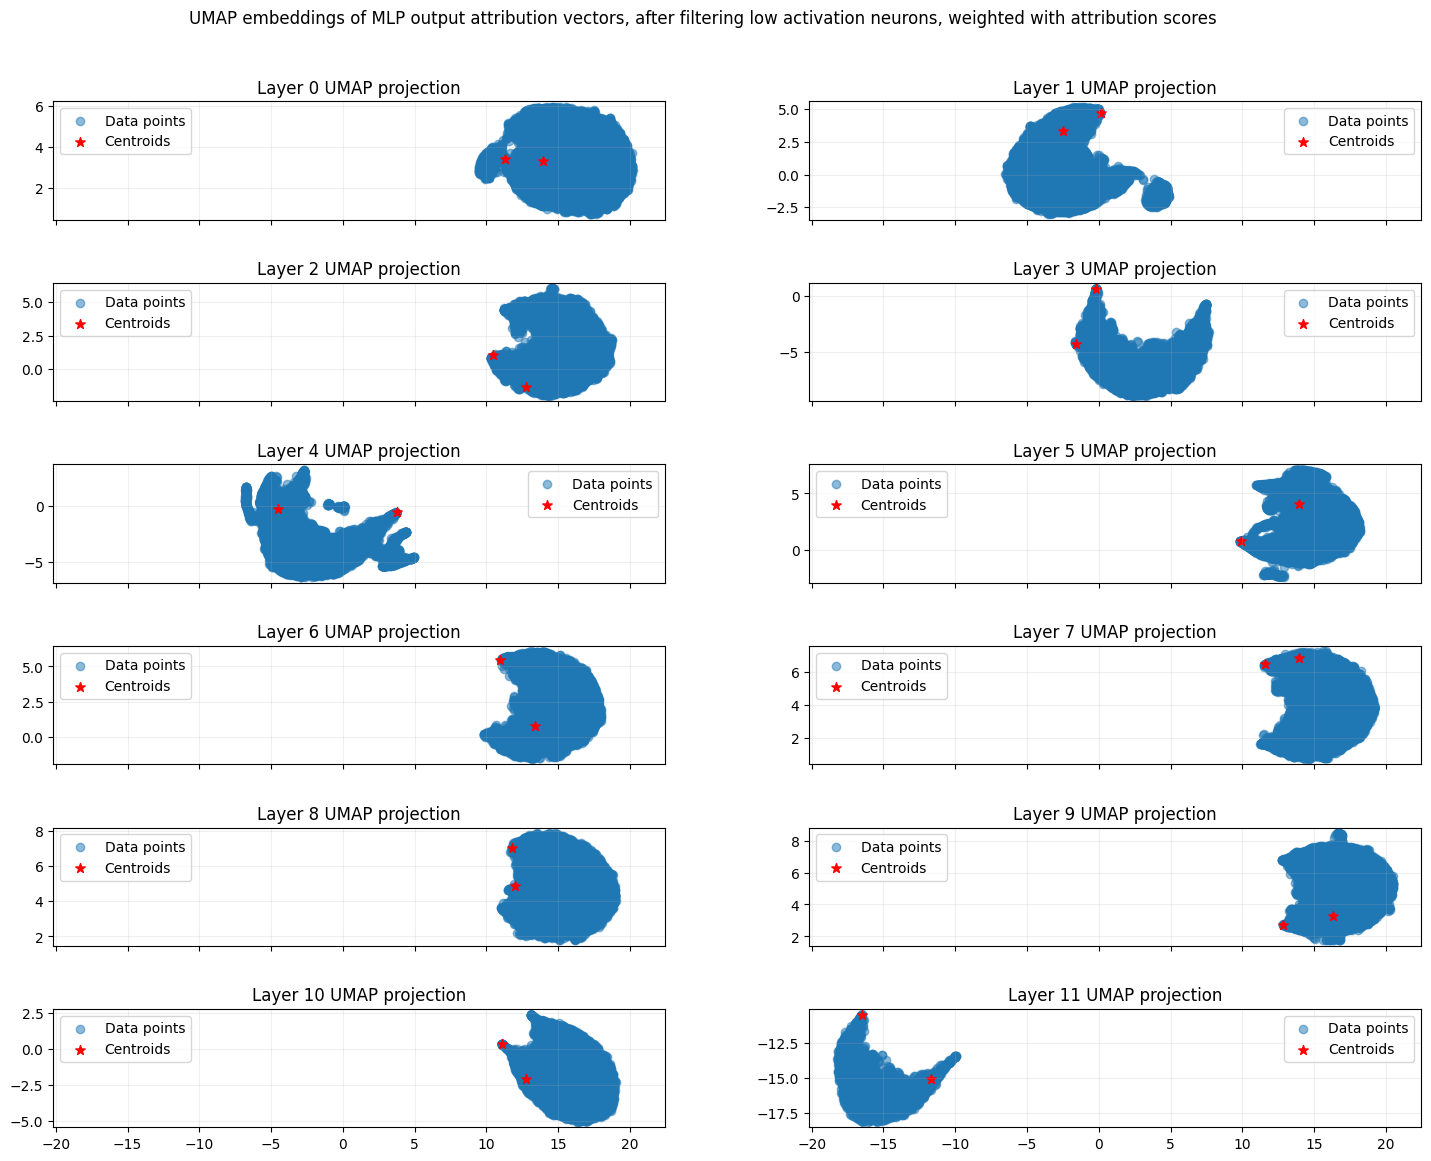

In [27]:
fig, axes = plt.subplots(6, 2, sharex=True, figsize=(7, 8))

l=0
for ax in axes:
    for subplot in ax:
        non_empty_mask = attr[l].abs().sum(dim=1).bool()
        data = attr[l,non_empty_mask,:].cpu().detach().numpy()
        
        subplot.scatter(embeddings[l][:len(data), 0], embeddings[l][:len(data), 1], alpha=0.5, label='Data points')
        subplot.scatter(embeddings[l][len(data):, 0], embeddings[l][len(data):, 1], c='red', marker='*', s=50, label='Centroids')
        subplot.set_title(f'Layer {l} UMAP projection')
        subplot.legend()
        subplot.grid(alpha=0.2)

        l+=1

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space at top for suptitle
plt.suptitle('UMAP embeddings of MLP output attribution vectors, after filtering low activation neurons, weighted with attribution scores')
plt.gcf().set_size_inches(15, 12)  # Make the figure wider